In [2]:
import glob
import numpy as np
import pandas as pd
import os
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
all_paths = glob.glob('data/cat_stageagecancer/*/*_1_*.npy')
stage_paths = [s for s in all_paths if '_stage.' in s]

In [14]:
test = np.load(stage_paths[0])
test.shape

(198, 4)

In [17]:
base_dir = 'data/cat_stageagecancer'

In [27]:
len(y_true)

199

In [78]:
for repeat in range(n_repeats):
    for fold in range(n_folds):
        

        # Load ground truth (ctest.npy) for this fold
        y_true_file = os.path.join(base_dir, f"{repeat}/{fold}_1_ctest.npy")
        y_true_all = np.load(y_true_file)

FileNotFoundError: [Errno 2] No such file or directory: '/path/to/results/0/0_1_ctest.npy'

In [29]:
y_true_all.shape

(199, 3)

In [ ]:
y_true = np.argmax(y_true_all[:, :4], axis=1)

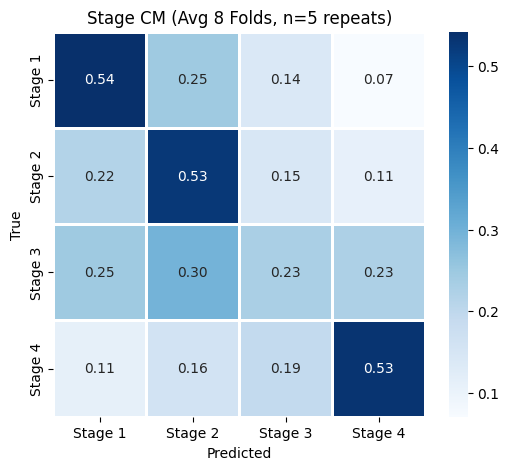

In [53]:
# Number of repeats and folds
n_repeats = 5
n_folds = 8

# Stage has 4 classes
n_classes = 4
conf_total = np.zeros((n_classes, n_classes), dtype=int)

for repeat in range(n_repeats):
    for fold in range(n_folds):
        
        pred_file = os.path.join(base_dir, f"{repeat}/{fold}_1_stage.npy")
        y_pred_probs = np.load(pred_file)
        y_pred = np.argmax(y_pred_probs, axis=1)

        # Load ground truth (ctest.npy) for this fold
        y_true_file = os.path.join(base_dir, f"{repeat}/{fold}_1_ctest.npy")
        y_true_all = np.load(y_true_file)

        # Stage is first 4 columns in ctest
        y_true = y_true_all[:, 0]

        # Compute confusion matrix and add to total
        cm = confusion_matrix(y_true, y_pred, labels=range(n_classes))
        conf_total += cm

        
# Normalize row-wise
conf_norm = conf_total.astype(float) / conf_total.sum(axis=1, keepdims=True)
#conf_avg = conf_total.astype(float) / (n_repeats * n_folds)


# --- Plot heatmap ---
plt.figure(figsize=(6,5))
sns.heatmap(conf_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=[f"Stage {i+1}" for i in range(n_classes)],
            yticklabels=[f"Stage {i+1}" for i in range(n_classes)],
linewidths=0.75, linecolor="white")
plt.title("Stage CM (Avg 8 Folds, n=5 repeats)")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.savefig('stage_cm.png')
plt.show()


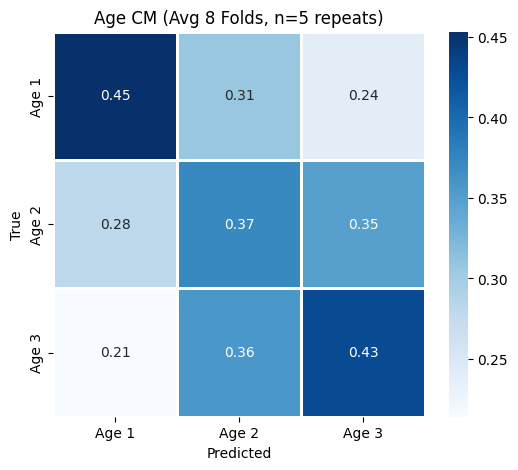

In [47]:
# Number of repeats and folds
n_repeats = 5
n_folds = 8

# Stage has 4 classes
n_classes = 3
conf_total = np.zeros((n_classes, n_classes), dtype=int)

for repeat in range(n_repeats):
    for fold in range(n_folds):
        
        pred_file = os.path.join(base_dir, f"{repeat}/{fold}_1_age.npy")
        y_pred_probs = np.load(pred_file)
        y_pred = np.argmax(y_pred_probs, axis=1)

        # Load ground truth (ctest.npy) for this fold
        y_true_file = os.path.join(base_dir, f"{repeat}/{fold}_1_ctest.npy")
        y_true_all = np.load(y_true_file)

        # Stage is first 4 columns in ctest
        y_true = y_true_all[:, 1]

        # Compute confusion matrix and add to total
        cm = confusion_matrix(y_true, y_pred, labels=range(n_classes))
        conf_total += cm

        
# Normalize row-wise
conf_norm = conf_total.astype(float) / conf_total.sum(axis=1, keepdims=True)
#conf_avg = conf_total.astype(float) / (n_repeats * n_folds)


# --- Plot heatmap ---
plt.figure(figsize=(6,5))
sns.heatmap(conf_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=[f"Age {i+1}" for i in range(n_classes)],
            yticklabels=[f"Age {i+1}" for i in range(n_classes)],
linewidths=0.75, linecolor="white")
plt.title("Age CM (Avg 8 Folds, n=5 repeats)")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.savefig('age_cm.png')
plt.show()


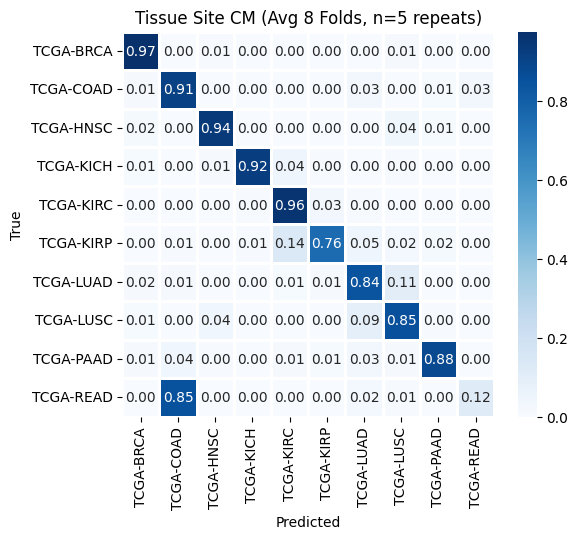

In [74]:
# Number of repeats and folds
n_repeats = 5
n_folds = 8

# Stage has 4 classes
n_classes = 10
conf_total = np.zeros((n_classes, n_classes), dtype=int)

for repeat in range(n_repeats):
    for fold in range(n_folds):
        
        pred_file = os.path.join(base_dir, f"{repeat}/{fold}_1_cancer.npy")
        y_pred_probs = np.load(pred_file)
        y_pred = np.argmax(y_pred_probs, axis=1)

        # Load ground truth (ctest.npy) for this fold
        y_true_file = os.path.join(base_dir, f"{repeat}/{fold}_1_ctest.npy")
        y_true_all = np.load(y_true_file)

        # Stage is first 4 columns in ctest
        y_true = y_true_all[:, 2]

        # Compute confusion matrix and add to total
        cm = confusion_matrix(y_true, y_pred, labels=range(n_classes))
        conf_total += cm

        
# Normalize row-wise
conf_norm = conf_total.astype(float) / conf_total.sum(axis=1, keepdims=True)
#conf_avg = conf_total.astype(float) / (n_repeats * n_folds)


# --- Plot heatmap ---
plt.figure(figsize=(6,5))
sns.heatmap(conf_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=[f"{site_map[i]}" for i in range(n_classes)],
            yticklabels=[f"{site_map[i]}" for i in range(n_classes)],
linewidths=0.75, linecolor="white")
plt.title("Tissue Site CM (Avg 8 Folds, n=5 repeats)")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.savefig('tissue_site_cm.png')
plt.show()


In [57]:
strat = pd.read_csv('data/strat.csv')

In [68]:
site_map = dict(set(list(zip(list(strat['project_id_x']),strat['Cancer']))))

In [61]:
strat

,Unnamed: 0.2,Unnamed: 0.1,case_id,project_id_x,Stage,Age,case_submitter_id_x,Cancer,vital_status,days_to_death,days_to_last_follow_up,18_months,24_months,36_months,Survival,120_months,ID,RNA_Bio,RNA_Bio_z,RNA_Bio_bin,Unnamed: 0,stage_var_0,stage_var_1,stage_var_2,stage_var_3,age_group_2,age_group_1,age_group_0,project_id_9,project_id_0,project_id_4,project_id_7,project_id_6,project_id_1,project_id_2,project_id_8,project_id_3,project_id_5,stratify_col,test,RNA_Bio_ter,RNA_Bio_ter_low,RNA_Bio_ter_mid,RNA_Bio_ter_high
0,0,0,ff8dac97-42ff-4f48-81c4-50315ad8de58,TCGA-PAAD,1,0,TCGA-FB-AAQ1,8,Dead,123.0,NaN,Died,Died,Died,1,Died,TCGA-FB-AAQ1,4.667704,2.927864,1,148,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0-1-0-0-1-0-0,6,2,0,0,1
1,1,1,3e1886a8-2ed2-41ee-8b58-10f5321ade6f,TCGA-COAD,1,2,TCGA-DM-A28K,1,Alive,NaN,2988.0,Alive,Alive,Alive,0,Censored,TCGA-DM-A28K,2.271262,0.123785,1,182,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0-1-0-0-0-0-1,1,1,0,1,0
2,2,2,4b22ad71-c585-4077-ad3c-c6e026d0c7fa,TCGA-LUAD,1,1,TCGA-44-7669,6,Dead,574.0,NaN,Alive,Died,Died,1,Died,TCGA-44-7669,1.620826,-0.637290,0,175,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0-1-0-0-0-1-0,0,0,1,0,0
3,3,3,452135f2-6de6-4593-a091-ddf6344ee431,TCGA-KICH,1,1,TCGA-KL-8328,3,Alive,NaN,3127.0,Alive,Alive,Alive,0,Censored,TCGA-KL-8328,0.662913,-1.758144,0,57,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0-1-0-0-0-1-0,6,0,1,0,0
4,4,4,93b742eb-5fc3-4ce2-b7f6-c89f97e0dcc9,TCGA-HNSC,1,1,TCGA-CV-7263,2,Dead,560.0,NaN,Alive,Died,Died,1,Died,TCGA-CV-7263,1.809049,-0.417051,0,1109,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0-1-0-0-0-1-0,2,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1589,1589,1589,3e637872-f5e5-49d3-bb0d-9c16b8713382,TCGA-BRCA,3,0,TCGA-LL-A73Z,0,Dead,227.0,137.0,Died,Died,Died,1,Died,TCGA-LL-A73Z,1.680506,-0.567459,0,1573,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0-0-0-1-1-0-0,1,0,1,0,0
1590,1590,1590,3a0775a0-61ae-43f2-b5f6-629a44355c2f,TCGA-BRCA,0,1,TCGA-GM-A2DK,0,Alive,NaN,2645.0,Alive,Alive,Alive,0,Censored,TCGA-GM-A2DK,0.918979,-1.458522,0,743,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1-0-0-0-0-1-0,5,0,1,0,0
1591,1591,1591,d5619045-060a-4b60-86e4-6a5774994fd4,TCGA-COAD,3,2,TCGA-AA-3989,1,Dead,242.0,0.0,Died,Died,Died,1,Died,TCGA-AA-3989,1.398425,-0.897521,0,1175,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0-0-0-1-0-0-1,0,0,1,0,0
1592,1592,1592,8fc1f1be-d2d5-4b3a-9973-f4d964018beb,TCGA-HNSC,2,1,TCGA-CV-5973,2,Alive,NaN,2641.0,Alive,Alive,Alive,0,Censored,TCGA-CV-5973,2.655133,0.572953,1,1622,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0-0-1-0-0-1-0,2,2,0,0,1


In [70]:
site_map = {v:k for k, v in site_map.items()}

In [71]:
### Misclassification by 1

{3: 'TCGA-KICH',
 0: 'TCGA-BRCA',
 8: 'TCGA-PAAD',
 2: 'TCGA-HNSC',
 9: 'TCGA-READ',
 1: 'TCGA-COAD',
 4: 'TCGA-KIRC',
 5: 'TCGA-KIRP',
 6: 'TCGA-LUAD',
 7: 'TCGA-LUSC'}

In [75]:
def tolerant_predictions(y_true, y_pred, n_classes):
    """
    Adjust predictions so that misclassifications by ±1
    are treated as correct.
    """
    y_pred_tol = []
    for yt, yp in zip(y_true, y_pred):
        if abs(yt - yp) <= 1:
            y_pred_tol.append(yt)   # treat as correct (force to true label)
        else:
            y_pred_tol.append(yp)   # keep misclassification
    return np.array(y_pred_tol)


In [ ]:
from sklearn.metrics import confusion_matrix, f1_score

y_true = np.array([0,0,1,1,2,2,3,3])   # example stages
y_pred = np.array([0,1,2,0,3,1,2,0])   # predictions

# tolerant predictions
y_pred_tol = tolerant_predictions(y_true, y_pred, n_classes=4)

print("Standard Confusion:")
print(confusion_matrix(y_true, y_pred, labels=range(4)))

print("Misclass-by-1 Confusion:")
print(confusion_matrix(y_true, y_pred_tol, labels=range(4)))

print("Standard F1:", f1_score(y_true, y_pred, average="macro"))
print("Misclass-by-1 F1:", f1_score(y_true, y_pred_tol, average="macro"))


Average Confusion Matrix (Normal):
 [[29.325 13.4    7.55   3.85 ]
 [13.975 33.775  9.3    7.075]
 [10.475 12.55   9.75   9.6  ]
 [ 4.275  6.025  7.3   20.15 ]]
Average Confusion Matrix (Misclass-by-1):
 [[0.78937644 0.         0.13949192 0.07113164]
 [0.         0.88966862 0.         0.11033138]
 [0.24719764 0.         0.75280236 0.        ]
 [0.11324503 0.15960265 0.         0.72715232]]
Mean F1 (Normal): 0.4482993640651925
Mean F1 (Misclass-by-1): 0.7888345017871359


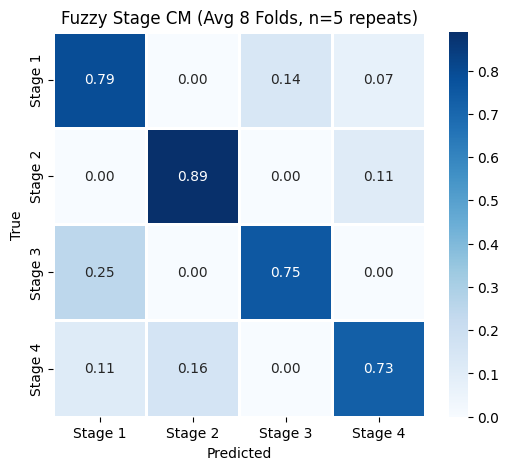

In [94]:
import os
import numpy as np
from sklearn.metrics import confusion_matrix, f1_score

def tolerant_predictions(y_true, y_pred):
    """
    Adjust predictions so that misclassifications by ±1
    are treated as correct (force pred to true if within ±1).
    """
    y_pred_tol = []
    for yt, yp in zip(y_true, y_pred):
        if abs(yt - yp) <= 1:
            y_pred_tol.append(yt)  # treat as correct
        else:
            y_pred_tol.append(yp)  # keep misclassification
    return np.array(y_pred_tol)

# Parameters
n_repeats = 5
n_folds = 8
n_classes = 4
base_dir = 'data/cat_stageagecancer'  # change to your folder

# Storage
conf_total_normal = np.zeros((n_classes, n_classes), dtype=int)
conf_total_tol = np.zeros((n_classes, n_classes), dtype=int)
f1_scores_normal = []
f1_scores_tol = []

for repeat in range(n_repeats):
    for fold in range(n_folds):
        # --- Load predictions for stage ---
        pred_file = os.path.join(base_dir, f"{repeat}/{fold}_1_stage.npy")
        y_pred_probs = np.load(pred_file)
        y_pred = np.argmax(y_pred_probs, axis=1)

        # --- Load ground truth (ctest.npy) ---
        y_true_file = os.path.join(base_dir, f"{repeat}/{fold}_1_ctest.npy")
        y_true_all = np.load(y_true_file)
        y_true = y_true_all[:, 0]

        # --- Normal confusion matrix ---
        cm = confusion_matrix(y_true, y_pred, labels=range(n_classes))
        conf_total_normal += cm

        # --- Tolerant predictions (±1) ---
        y_pred_tol = tolerant_predictions(y_true, y_pred)

        # --- Tolerant confusion matrix ---
        cm_tol = confusion_matrix(y_true, y_pred_tol, labels=range(n_classes))
        conf_total_tol += cm_tol

        # --- F1 scores ---
        f1_scores_normal.append(f1_score(y_true, y_pred, average="macro"))
        f1_scores_tol.append(f1_score(y_true, y_pred_tol, average="macro"))

# --- Aggregate results ---
#conf_avg_normal = conf_total_normal / (n_repeats * n_folds)
#conf_avg_tol = conf_total_tol / (n_repeats * n_folds)

conf_norm = conf_total_normal.astype(float) / conf_total_normal.sum(axis=1, keepdims=True)
conf_avg_tol = conf_total_tol.astype(float) / conf_total_tol.sum(axis=1, keepdims=True)

f1_normal_mean = np.mean(f1_scores_normal)
f1_tol_mean = np.mean(f1_scores_tol)

print("Average Confusion Matrix (Normal):\n", conf_avg_normal)
print("Average Confusion Matrix (Misclass-by-1):\n", conf_avg_tol)
print("Mean F1 (Normal):", f1_normal_mean)
print("Mean F1 (Misclass-by-1):", f1_tol_mean)

# Normalize row-wise
#conf_norm = conf_total.astype(float) / conf_total.sum(axis=1, keepdims=True)
#conf_avg = conf_total.astype(float) / (n_repeats * n_folds)


# --- Plot heatmap ---
plt.figure(figsize=(6,5))
sns.heatmap(conf_avg_tol, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=[f"Stage {i+1}" for i in range(n_classes)],
            yticklabels=[f"Stage {i+1}" for i in range(n_classes)],
linewidths=0.75, linecolor="white")
plt.title("Fuzzy Stage CM (Avg 8 Folds, n=5 repeats)")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.savefig('fuzzy_stage_cm.png')
plt.show()

Average Confusion Matrix (Normal):
 [[29.325 13.4    7.55   3.85 ]
 [13.975 33.775  9.3    7.075]
 [10.475 12.55   9.75   9.6  ]
 [ 4.275  6.025  7.3   20.15 ]]
Average Confusion Matrix (Misclass-by-1):
 [[0.76055227 0.         0.23944773]
 [0.         1.         0.        ]
 [0.21414914 0.         0.78585086]]
Mean F1 (Normal): 0.41356794948570386
Mean F1 (Misclass-by-1): 0.8482617958079262


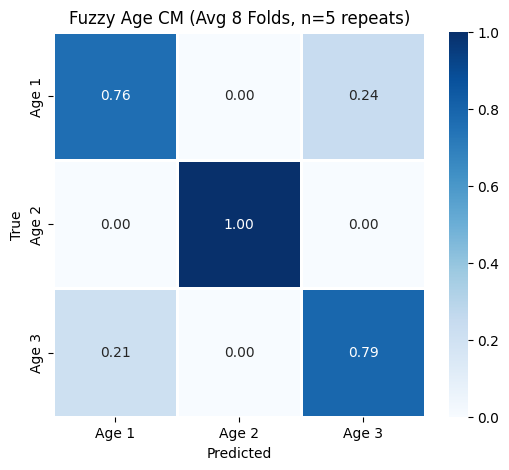

In [93]:
import os
import numpy as np
from sklearn.metrics import confusion_matrix, f1_score

def tolerant_predictions(y_true, y_pred):
    """
    Adjust predictions so that misclassifications by ±1
    are treated as correct (force pred to true if within ±1).
    """
    y_pred_tol = []
    for yt, yp in zip(y_true, y_pred):
        if abs(yt - yp) <= 1:
            y_pred_tol.append(yt)  # treat as correct
        else:
            y_pred_tol.append(yp)  # keep misclassification
    return np.array(y_pred_tol)

# Parameters
n_repeats = 5
n_folds = 8
n_classes = 3
base_dir = 'data/cat_stageagecancer'  # change to your folder

# Storage
conf_total_normal = np.zeros((n_classes, n_classes), dtype=int)
conf_total_tol = np.zeros((n_classes, n_classes), dtype=int)
f1_scores_normal = []
f1_scores_tol = []

for repeat in range(n_repeats):
    for fold in range(n_folds):
        # --- Load predictions for stage ---
        pred_file = os.path.join(base_dir, f"{repeat}/{fold}_1_age.npy")
        y_pred_probs = np.load(pred_file)
        y_pred = np.argmax(y_pred_probs, axis=1)

        # --- Load ground truth (ctest.npy) ---
        y_true_file = os.path.join(base_dir, f"{repeat}/{fold}_1_ctest.npy")
        y_true_all = np.load(y_true_file)
        y_true = y_true_all[:, 1]

        # --- Normal confusion matrix ---
        cm = confusion_matrix(y_true, y_pred, labels=range(n_classes))
        conf_total_normal += cm

        # --- Tolerant predictions (±1) ---
        y_pred_tol = tolerant_predictions(y_true, y_pred)

        # --- Tolerant confusion matrix ---
        cm_tol = confusion_matrix(y_true, y_pred_tol, labels=range(n_classes))
        conf_total_tol += cm_tol

        # --- F1 scores ---
        f1_scores_normal.append(f1_score(y_true, y_pred, average="macro"))
        f1_scores_tol.append(f1_score(y_true, y_pred_tol, average="macro"))

# --- Aggregate results ---
#conf_avg_normal = conf_total_normal / (n_repeats * n_folds)
#conf_avg_tol = conf_total_tol / (n_repeats * n_folds)

conf_norm = conf_total_normal.astype(float) / conf_total_normal.sum(axis=1, keepdims=True)
conf_avg_tol = conf_total_tol.astype(float) / conf_total_tol.sum(axis=1, keepdims=True)

f1_normal_mean = np.mean(f1_scores_normal)
f1_tol_mean = np.mean(f1_scores_tol)

print("Average Confusion Matrix (Normal):\n", conf_avg_normal)
print("Average Confusion Matrix (Misclass-by-1):\n", conf_avg_tol)
print("Mean F1 (Normal):", f1_normal_mean)
print("Mean F1 (Misclass-by-1):", f1_tol_mean)

# Normalize row-wise
#conf_norm = conf_total.astype(float) / conf_total.sum(axis=1, keepdims=True)
#conf_avg = conf_total.astype(float) / (n_repeats * n_folds)


# --- Plot heatmap ---
plt.figure(figsize=(6,5))
sns.heatmap(conf_avg_tol, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=[f"Age {i+1}" for i in range(n_classes)],
            yticklabels=[f"Age {i+1}" for i in range(n_classes)],
linewidths=0.75, linecolor="white")
plt.title("Fuzzy Age CM (Avg 8 Folds, n=5 repeats)")
plt.ylabel("True")
plt.xlabel("Predicted")
#plt.savefig('fuzzy_stage_cm.png')
plt.show()

In [95]:
import os
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt
import seaborn as sns

def tolerant_predictions(y_true, y_pred):
    """Force pred to true if within ±1."""
    return np.array([yt if abs(yt - yp) <= 1 else yp for yt, yp in zip(y_true, y_pred)])

# Parameters
n_repeats = 5
n_folds = 8
base_dir = 'data/cat_stageagecancer' 
n_classes = 4

# Storage per fold
fold_scores_normal = []
fold_scores_tol = []

for fold in range(n_folds):
    repeat_scores_normal = []
    repeat_scores_tol = []

    for repeat in range(n_repeats):
        # --- Load predictions ---
        pred_file = os.path.join(base_dir, f"{repeat}/{fold}_1_stage.npy")
        y_pred_probs = np.load(pred_file)
        y_pred = np.argmax(y_pred_probs, axis=1)

        # --- Load ground truth ---
        y_true_file = os.path.join(base_dir, f"{repeat}/{fold}_1_ctest.npy")
        y_true_all = np.load(y_true_file)
        y_true = np.argmax(y_true_all[:, :n_classes], axis=1)

        # --- Normal F1 ---
        f1_norm = f1_score(y_true, y_pred, average="macro")
        repeat_scores_normal.append(f1_norm)

        # --- Tolerant F1 ---
        y_pred_tol = tolerant_predictions(y_true, y_pred)
        f1_tol = f1_score(y_true, y_pred_tol, average="macro")
        repeat_scores_tol.append(f1_tol)

    # Average across repeats for this fold
    fold_scores_normal.append(np.mean(repeat_scores_normal))
    fold_scores_tol.append(np.mean(repeat_scores_tol))

# --- Convert to DataFrame for plotting ---
df = pd.DataFrame({
    "Fold": np.arange(1, n_folds+1),
    "Normal": fold_scores_normal,
    "Misclass-by-1": fold_scores_tol
}).melt(id_vars="Fold", var_name="Metric", value_name="F1")

# --- Stats ---
stat, p = wilcoxon(fold_scores_normal, fold_scores_tol)

print(f"Wilcoxon test Normal vs Misclass-by-1: stat={stat:.3f}, p={p:.4f}")

# --- Plot ---
plt.figure(figsize=(6,5))
sns.barplot(data=df, x="Metric", y="F1", palette=["orange","gold"], ci="sd", edgecolor="black")
sns.stripplot(data=df, x="Metric", y="F1", color="black", size=5, jitter=True)

plt.title(f"Stage F1 vs Misclass-by-1 (8-fold avg, Wilcoxon p={p:.4f})")
plt.ylabel("F1 Score")
plt.xlabel("")
plt.tight_layout()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '/path/to/results/0/0_1_stage.npy'

In [115]:
# Load files
bin_file = "data/fold_test_bin_stageagecancer.csv"
#cat_file = "data/fold_test_cat_stageagecancer.csv"

df_bin = pd.read_csv(bin_file)
#df_cat = pd.read_csv(cat_file)

# Subset lambda=1
df_bin = df_bin[df_bin["lambda"] == 1]
#df_cat = df_cat[df_cat["lambda"] == 1]

# --- Parse concepts ---
# Bin: average 4 (Stage), 3 (Age), 10 (Cancer)
def split_bin_concepts(row):
    vals = [float(x) for x in row.strip("[]").split(",")]
    stage = np.mean(vals[:4])
    age = np.mean(vals[4:7])
    cancer = np.mean(vals[7:17])
    return stage, age, cancer

bin_concepts = df_bin["concepts"].apply(split_bin_concepts)
df_bin[["stage_f1","age_f1","cancer_f1"]] = pd.DataFrame(bin_concepts.tolist(), index=df_bin.index)

# Cat: parse 3 values directly
def split_cat_concepts(row):
    vals = [float(x) for x in row.strip("[]").split(",")]
    return vals

"""
cat_concepts = df_cat["concepts"].apply(split_cat_concepts)
df_cat[["stage_f1","age_f1","cancer_f1"]] = pd.DataFrame(cat_concepts.tolist(), index=df_cat.index)
"""
# --- Average across repeats within folds ---
def avg_within_folds(df, model_type):
    grouped = df.groupby("fold").agg({
        "task_f1s":"mean",
        "stage_f1":"mean",
        "age_f1":"mean",
        "cancer_f1":"mean"
    }).reset_index()
    grouped["model"] = model_type
    return grouped


In [116]:
bin_avg = avg_within_folds(df_bin, "Bin")

In [117]:
bin_avg

,fold,task_f1s,stage_f1,age_f1,cancer_f1,model
0,0,0.749702,0.335175,0.223930,0.757126,Bin
1,1,0.761958,0.338929,0.300194,0.751902,Bin
2,2,0.754541,0.352744,0.314090,0.791257,Bin
3,3,0.760590,0.416050,0.291071,0.706207,Bin
4,4,0.697292,0.371602,0.240185,0.777385,Bin
5,5,0.768994,0.338251,0.271667,0.770295,Bin
6,6,0.749417,0.351979,0.300334,0.730373,Bin
7,7,0.767218,0.393904,0.263001,0.745329,Bin


Stage Normal vs ±1: stat=0.000, p=0.0078
Age Normal vs ±1: stat=0.000, p=0.0078


/var/folders/wj/bwk4b7356cn68vctc2ddsfhh0000gr/T/ipykernel_14093/1382838663.py:89: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=df_melt, x="Metric", y="F1", palette=palette, ci="sd", edgecolor="black")
/var/folders/wj/bwk4b7356cn68vctc2ddsfhh0000gr/T/ipykernel_14093/1382838663.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_melt, x="Metric", y="F1", palette=palette, ci="sd", edgecolor="black")


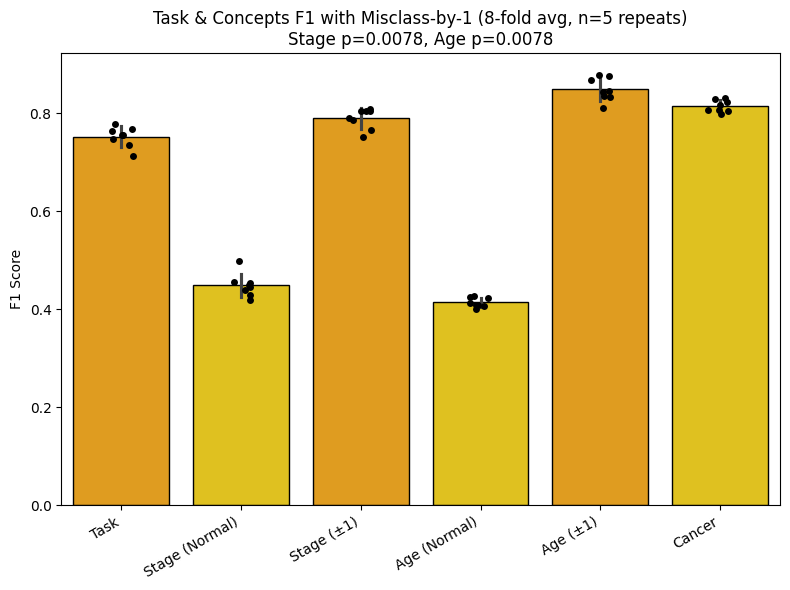

In [4]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
from scipy.stats import wilcoxon

# --- Misclassification-by-1 helper ---
def tolerant_predictions(y_true, y_pred):
    return np.array([yt if abs(yt - yp) <= 1 else yp for yt, yp in zip(y_true, y_pred)])

# --- Parameters ---
n_repeats = 5
n_folds = 8
base_dir = 'data/cat_stageagecancer' 
n_stage = 4
n_age = 3
n_cancer = 10

# --- Storage ---
fold_results = []

for fold in range(n_folds):
    # Per-fold collections
    task_repeat, stage_repeat, stage_tol_repeat = [], [], []
    age_repeat, age_tol_repeat, cancer_repeat = [], [], []

    for repeat in range(n_repeats):
        # === Load ground truth ===
        y_true_file = os.path.join(base_dir, f"{repeat}/{fold}_1_ctest.npy")
        y_true_all = np.load(y_true_file)
        y_true_task_file = os.path.join(base_dir, f"{repeat}/{fold}_1_ytrue.npy")
        y_true_task = np.load(y_true_task_file)

        # Extract concepts
        y_true_stage = y_true_all[:, 0]
        y_true_age = y_true_all[:, 1]
        y_true_cancer = y_true_all[:, 2]
        #y_true_task = y_true_all[:, 3], axis=1)

        # === Load predictions ===
        y_pred_stage = np.argmax(np.load(os.path.join(base_dir, f"{repeat}/{fold}_1_stage.npy")), axis=1)
        y_pred_age = np.argmax(np.load(os.path.join(base_dir, f"{repeat}/{fold}_1_age.npy")), axis=1)
        y_pred_cancer = np.argmax(np.load(os.path.join(base_dir, f"{repeat}/{fold}_1_cancer.npy")), axis=1)
        y_pred_task = (np.load(os.path.join(base_dir, f"{repeat}/{fold}_1_yprobs.npy")) > 0.5).astype(int)

        # === F1 scores ===
        task_repeat.append(f1_score(y_true_task, y_pred_task))

        # Stage
        stage_repeat.append(f1_score(y_true_stage, y_pred_stage, average="macro"))
        y_pred_stage_tol = tolerant_predictions(y_true_stage, y_pred_stage)
        stage_tol_repeat.append(f1_score(y_true_stage, y_pred_stage_tol, average="macro"))

        # Age
        age_repeat.append(f1_score(y_true_age, y_pred_age, average="macro"))
        y_pred_age_tol = tolerant_predictions(y_true_age, y_pred_age)
        age_tol_repeat.append(f1_score(y_true_age, y_pred_age_tol, average="macro"))

        # Cancer
        cancer_repeat.append(f1_score(y_true_cancer, y_pred_cancer, average="macro"))

    # === Average across repeats (per fold) ===
    fold_results.append({
        "Fold": fold+1,
        "Task": np.mean(task_repeat),
        "Stage (Normal)": np.mean(stage_repeat),
        "Stage (±1)": np.mean(stage_tol_repeat),
        "Age (Normal)": np.mean(age_repeat),
        "Age (±1)": np.mean(age_tol_repeat),
        "Cancer": np.mean(cancer_repeat)
    })

# --- DataFrame ---
df = pd.DataFrame(fold_results)
df_melt = df.melt(id_vars="Fold", var_name="Metric", value_name="F1")

# --- Stats ---
stat_stage, p_stage = wilcoxon(df["Stage (Normal)"], df["Stage (±1)"])
stat_age, p_age = wilcoxon(df["Age (Normal)"], df["Age (±1)"])

print(f"Stage Normal vs ±1: stat={stat_stage:.3f}, p={p_stage:.4f}")
print(f"Age Normal vs ±1: stat={stat_age:.3f}, p={p_age:.4f}")

# --- Plot ---
plt.figure(figsize=(8,6))
palette = ["orange","gold","orange","gold","orange","gold"]  # consistent colors
sns.barplot(data=df_melt, x="Metric", y="F1", palette=palette, ci="sd", edgecolor="black")
sns.stripplot(data=df_melt, x="Metric", y="F1", color="black", size=5, jitter=True)

plt.title(
    f"Task & Concepts F1 with Misclass-by-1 (8-fold avg, n=5 repeats)\n"
    f"Stage p={p_stage:.4f}, Age p={p_age:.4f}"
)
plt.ylabel("F1 Score")
plt.xlabel("")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


In [5]:
df_cat = df[['Fold', 'Task', 'Stage (±1)','Age (±1)', 'Cancer']]
df_cat = df_cat.rename(columns={'Stage (±1)':'Stage','Age (±1)':'Age'})
df_cat

,Fold,Task,Stage,Age,Cancer
0,1,0.735413,0.804816,0.878213,0.816011
1,2,0.756079,0.808564,0.867189,0.805756
2,3,0.755181,0.764585,0.874825,0.828725
3,4,0.778275,0.789588,0.833517,0.806177
4,5,0.713063,0.751142,0.834751,0.822107
5,6,0.746669,0.784775,0.844679,0.798467
6,7,0.768103,0.803688,0.810747,0.830270
7,8,0.763646,0.803517,0.842173,0.803466


In [6]:
# --- Assume you already have: ---
# df_bin  = DataFrame with columns ["fold", "task_f1s", "stage_f1", "age_f1", "cancer_f1"]
# df_cat  = DataFrame with fold-level averages for Task, Stage (Normal + ±1), Age (Normal + ±1), Cancer

# Reshape Binary
df_bin_long = df_bin.melt(
    id_vars="fold", 
    value_vars=["task_f1s","stage_f1","age_f1","cancer_f1"],
    var_name="Metric", value_name="F1"
)
df_bin_long["Model"] = "Bin"
df_bin_long["Metric"] = df_bin_long["Metric"].map({
    "task_f1s":"Task", "stage_f1":"Stage", "age_f1":"Age", "cancer_f1":"Cancer"
})

pal = sns.light_palette("#4c72b0", n_colors=1, reverse=True) 

# Reshape Categorical
df_cat_long = df_cat.melt(
    id_vars="Fold", 
    var_name="Metric", value_name="F1"
).rename(columns={"Fold":"fold"})
df_cat_long["Model"] = "Cat"

# Combine
#df_all = pd.concat([df_bin_long, df_cat_long], ignore_index=True)

# --- Plot ---
plt.figure(figsize=(10,6))
sns.barplot(
    data=df_cat_long, x="Metric", y="F1", hue="Model", 
    palette=pal, ci="sd", edgecolor="black"
)
sns.stripplot(
    data=df_cat_long, x="Metric", y="F1", hue="Model",
    dodge=True, color="w", size=4, jitter=True, alpha=0.7
)

plt.title("Cat Model F1 (with ±1 tolerance for Stage & Age)")
plt.ylabel("F1 Score")
plt.xlabel("")
plt.xticks(rotation=20)
plt.legend(title="", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig('fuzzy_barplot_3concepts.png')
plt.show()

# --- Stats ---
results = {}
for metric in df_all["Metric"].unique():
    bin_vals = df_all[(df_all["Metric"]==metric) & (df_all["Model"]=="Bin")]["F1"].values
    cat_vals = df_all[(df_all["Metric"]==metric) & (df_all["Model"]=="Cat")]["F1"].values
    if len(bin_vals)==len(cat_vals):
        stat, p = wilcoxon(bin_vals, cat_vals)
        results[metric] = p

print("Wilcoxon p-values:", results)


NameError: name 'df_bin' is not defined

In [8]:
# Reshape Categorical
df_cat_long = df_cat.melt(
    id_vars="Fold", 
    var_name="Metric", value_name="F1"
).rename(columns={"Fold":"fold"})
df_cat_long["Model"] = "Cat"

/var/folders/wj/bwk4b7356cn68vctc2ddsfhh0000gr/T/ipykernel_14093/3665091174.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  ax = sns.barplot(
/var/folders/wj/bwk4b7356cn68vctc2ddsfhh0000gr/T/ipykernel_14093/3665091174.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


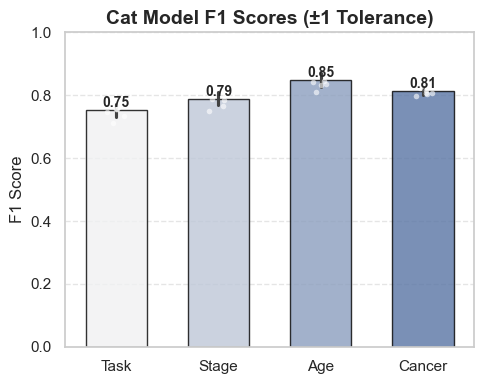

In [13]:
# Modern Minimal Style
plt.figure(figsize=(5,4))
sns.set_theme(style="whitegrid")

pal = sns.light_palette("#4c72b0", n_colors=4) 

ax = sns.barplot(
    data=df_cat_long, x="Metric", y="F1", alpha=0.8, edgecolor="black", ci="sd", palette = pal, width=0.6
)

# Swarmplot instead of stripplot (better spread)
sns.stripplot(
    data=df_cat_long, x="Metric", y="F1", 
    color="w", size=4, alpha=0.6
)

# Add mean value labels above bars
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}", 
        (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha="center", va="bottom", fontsize=10, fontweight="bold"
    )

ax.set_title("Cat Model F1 Scores (±1 Tolerance)", fontsize=14, fontweight="bold")
ax.set_ylabel("F1 Score", fontsize=12)
ax.set_xlabel("")
ax.set_ylim(0, 1.0)
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.legend([],[], frameon=False)  # Hide legend since only Cat model here

plt.tight_layout()
plt.savefig("f1_modern_minimal.png", dpi=300)
plt.show()


/var/folders/wj/bwk4b7356cn68vctc2ddsfhh0000gr/T/ipykernel_14093/1307090169.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  ax = sns.barplot(
/var/folders/wj/bwk4b7356cn68vctc2ddsfhh0000gr/T/ipykernel_14093/1307090169.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


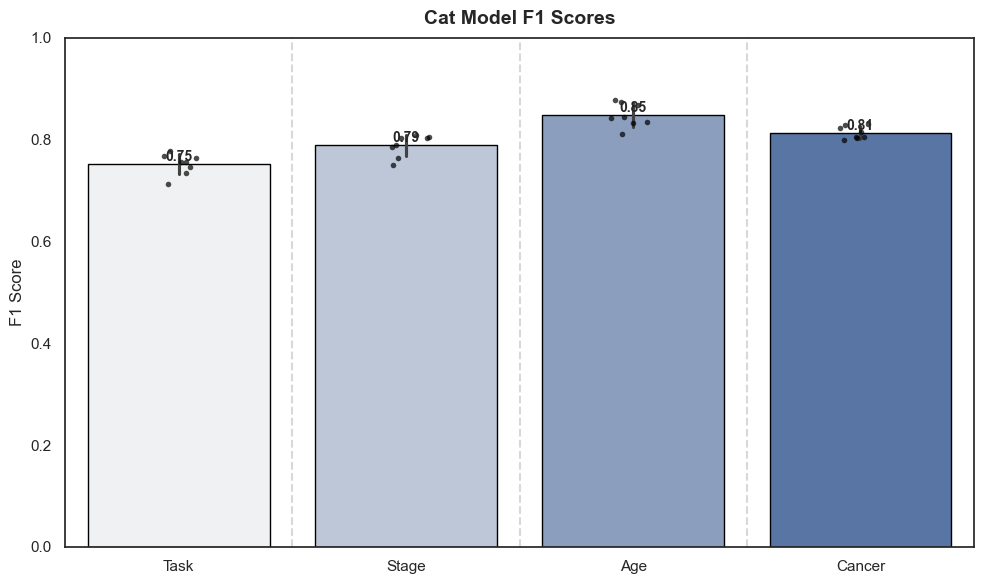

In [28]:
# Soft Gradient Style
plt.figure(figsize=(10,6))
sns.set_theme(style="white")

# Custom gradient palette
gradient_colors = sns.light_palette("#4c72b0", n_colors=4)

ax = sns.barplot(
    data=df_cat_long, x="Metric", y="F1", 
    palette=gradient_colors, edgecolor="black", ci="sd"
)

# Overlay stripplot dots in darker shade ofsame gradient
sns.stripplot(
    data=df_cat_long, x="Metric", y="F1", 
    color="black", size=4, alpha=0.7, jitter=True
)

# Add values above bars
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}", 
        (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha="center", va="bottom", fontsize=10, fontweight="semibold"
    )

# Title + subtitle styling
ax.set_title("Cat Model F1 Scores", fontsize=14, fontweight="bold", pad=10)
ax.set_xlabel("")
ax.set_ylabel("F1 Score", fontsize=12)
ax.set_ylim(0, 1.0)

# Light separators between categories
for x in range(len(df_cat_long["Metric"].unique())-1):
    ax.axvline(x+0.5, color="gray", linestyle="--", alpha=0.3)

ax.legend([],[], frameon=False)  # Hide legend

plt.tight_layout()
plt.savefig("f1_soft_gradient.png", dpi=300)
plt.show()


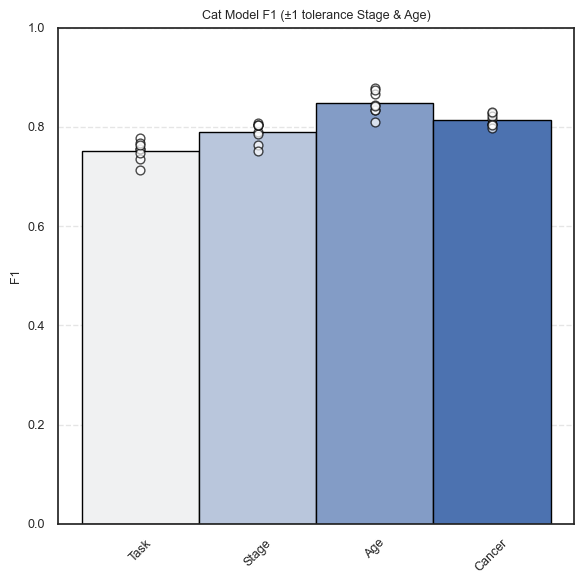

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="white")
# Prepare data
metrics = df_cat_long["Metric"].unique()
means = df_cat_long.groupby("Metric")["F1"].mean().reindex(metrics)

# Colors similar to your seaborn blues
colors = sns.light_palette("#4c72b0", n_colors=4)

# X positions for bars
x = np.arange(len(metrics))

plt.figure(figsize=(6,6))

# Plot bars with no spacing
bars = plt.bar(
    x, means, 
    color=colors, edgecolor="black", width=1.0  # width=1 means flush bars
)

# Add scatter points for folds
for i, metric in enumerate(metrics):
    yvals = df_cat_long[df_cat_long["Metric"]==metric]["F1"].values
    plt.scatter(
        np.full_like(yvals, x[i]), yvals,
        color="white", edgecolor="black", alpha=0.7, s=40, zorder=3
    )

# Add value labels above bars


# Style
plt.xticks(x, metrics, fontsize=9, rotation=45)
plt.yticks(fontsize=9)
plt.ylabel("F1", fontsize=9)
plt.ylim(0, 1.0)
plt.title("Cat Model F1 (±1 tolerance Stage & Age)", fontsize=9)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig('missclassification_bar.png', dpi=300, bbox_inches="tight")
plt.show()
